<a href="https://colab.research.google.com/github/pradipdas9040/Machine-Learning-2/blob/main/AgenticAI/08_fault_tolerance_chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!pip install langchain-ollama

In [2]:
%%capture
!sudo apt-get install -y zstd

In [3]:
%%capture
!curl -fsSL https://ollama.com/install.sh | sh

In [4]:
import subprocess
import os
import time

def connect_ollama_server():

  os.environ['OLLAMA_HOST'] = '0.0.0.0' # Set OLLAMA_HOST to '0.0.0.0' to make it accessible from inside the Colab VM.

  if 'ollama_process' in globals() and ollama_process.poll() is None:
      ollama_process.terminate()
      ollama_process.wait()
      print("Previous Ollama server terminated.")

  ollama_process = subprocess.Popen(['ollama', 'serve'])

  time.sleep(10)

  print("Ollama server started.")

connect_ollama_server()

Ollama server started.


In [5]:
%%capture
!ollama pull llama2:7b-chat

In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
import operator
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
import time

In [7]:
llm = ChatOllama(
    model="llama2:7b-chat",
    temperature=0.7 # A higher temperature for more creative generation
)

In [8]:
class JokeState(TypedDict):
  topic: str
  joke: str
  explanation: str
  joke_sentiment: str

In [9]:
def generate_joke(state: JokeState):
  topic = state["topic"]
  prompt = f"Generate a joke on the topic {topic}"
  responce = llm.invoke(prompt).content
  print("generate_joke executed")
  return {"joke": responce}

def generate_explanation(state: JokeState):
  joke = state["joke"]
  prompt = f"Write an explanation for the joke - {joke}"
  print("generate_explanation hanging...manually interrupt")
  time.sleep(30)
  responce = llm.invoke(prompt).content
  return {"explanation": responce}

def get_joke_sentiment(state: JokeState):
  joke = state["joke"]
  prompt = f"Write a sentiment for the joke - {joke}"
  responce = llm.invoke(prompt).content
  print("get_joke_sentiment executed")
  return {"joke_sentiment": responce}

In [10]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explanation", generate_explanation)
graph.add_node("get_joke_sentiment", get_joke_sentiment)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge("generate_explanation", "get_joke_sentiment")
graph.add_edge("get_joke_sentiment", END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

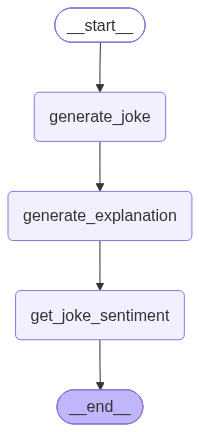

In [11]:
workflow

In [12]:
try:
  print("Running graph: manually interrupt during generate_explanation")
  config1 = {"configurable": {"thread_id": "1"}}
  workflow.invoke({"topic": "pizza"}, config=config1)
except KeyboardInterrupt:
  print("Kernel manually interrupt")

Running graph: manually interrupt during generate_explanation
generate_joke executed
generate_explanation hanging...manually interrupt
Kernel manually interrupt


In [13]:
workflow.get_state(config1) # final stste values

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy? It had a crust issue!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f186503-cda4-69f0-8001-1f0ed5be8d86'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-23T04:37:40.163987+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f186501-4c5e-6bd9-8000-f2f74abf712c'}}, tasks=(PregelTask(id='7dde41c4-bf20-b448-6306-ef17e50b10d5', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [14]:
list(workflow.get_state_history(config1)) # intermidate state values

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy? It had a crust issue!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f186503-cda4-69f0-8001-1f0ed5be8d86'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-23T04:37:40.163987+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f186501-4c5e-6bd9-8000-f2f74abf712c'}}, tasks=(PregelTask(id='7dde41c4-bf20-b448-6306-ef17e50b10d5', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f186501-4c5e-6bd9-8000-f2f74abf712c'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-23T04:36:32.921682+00:00', pare

In [16]:
connect_ollama_server()

Ollama server started.


In [17]:
%%capture
!ollama pull llama2:7b-chat

In [18]:
result = workflow.invoke(None, config=config1)
result

generate_explanation hanging...manually interrupt
get_joke_sentiment executed


{'topic': 'pizza',
 'joke': 'Why did the pizza go to therapy? It had a crust issue!',
 'explanation': '\nAh, I see! The joke is a play on words, with "crust" having both its literal meaning (the outer layer of a pizza) and a pun on the phrase "core issues." So, the pizza went to therapy because it had a problem with its "crust," which is a clever and humorous twist on the usual reason why people go to therapy – to deal with their emotional or psychological issues. I hope that helps clarify things!',
 'joke_sentiment': '\n😂 The pun on "crust" is perfect! I can totally see why the pizza would need therapy after being subjected to such a cheesy (get it?) situation. The joke is both funny and relatable, as who hasn\'t had their fair share of crust issues in life? 🤣'}

In [19]:
workflow.get_state(config1) # final stste values

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy? It had a crust issue!', 'explanation': '\nAh, I see! The joke is a play on words, with "crust" having both its literal meaning (the outer layer of a pizza) and a pun on the phrase "core issues." So, the pizza went to therapy because it had a problem with its "crust," which is a clever and humorous twist on the usual reason why people go to therapy – to deal with their emotional or psychological issues. I hope that helps clarify things!', 'joke_sentiment': '\n😂 The pun on "crust" is perfect! I can totally see why the pizza would need therapy after being subjected to such a cheesy (get it?) situation. The joke is both funny and relatable, as who hasn\'t had their fair share of crust issues in life? 🤣'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18650a-8af3-6dd1-8003-af78d3a470ca'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-07-

In [20]:
list(workflow.get_state_history(config1)) # intermidate state values

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy? It had a crust issue!', 'explanation': '\nAh, I see! The joke is a play on words, with "crust" having both its literal meaning (the outer layer of a pizza) and a pun on the phrase "core issues." So, the pizza went to therapy because it had a problem with its "crust," which is a clever and humorous twist on the usual reason why people go to therapy – to deal with their emotional or psychological issues. I hope that helps clarify things!', 'joke_sentiment': '\n😂 The pun on "crust" is perfect! I can totally see why the pizza would need therapy after being subjected to such a cheesy (get it?) situation. The joke is both funny and relatable, as who hasn\'t had their fair share of crust issues in life? 🤣'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18650a-8af3-6dd1-8003-af78d3a470ca'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-07